# CutTrack, minimal version

Bygger på samma klasstruktur som den fullständiga planen i teknisk_plan.md:
`DailyLog`, `User` (bas) och `CutProfile` (barnklass, ärver från `User`).
Den fysiologiska matematiken (BMR/TDEE, kalorigolv, 7700-regeln,
tvågränsad taktbedömning, midjemått) är inte med i den här versionen.

Koden är uppdelad i tre filer, alla i samma mapp:
- `models.py`: `DailyLog`, `User`, `CutProfile`
- `analysis.py`: filhantering och diagram (`make_filename`, `save_profile`,
  `load_profile`, `export_logs_csv`, `import_logs_csv`, `plot_weight`)
- den här notebooken: UI-lagret (`show_welcome`, `ask_number`, `create_profile`,
  `log_today`, `run_menu`) samt test- och democeller

Alla exempelpersoner i den här notebooken heter Testperson 1, Testperson
och så vidare, ingen är en riktig person.

**Viktigt:** notebooken måste ligga i samma mapp som `models.py` och
`analysis.py`. Ändras något i en av `.py`-filerna medan notebooken är öppen
måste kerneln startas om (Restart), Python läser bara in en modul en gång
per körning.

In [1]:
from datetime import datetime
from unittest.mock import patch

from models import DailyLog, User, CutProfile
from analysis import make_filename, save_profile, load_profile, export_logs_csv, import_logs_csv, plot_weight

## UI-lagret

`ask_number` frågar om igen tills svaret går att tolka som ett tal,
`ValueError` fångas i en `while True`-loop. `create_profile` har en egen
`while`-loop för kön av samma anledning: fråga om igen tills svaret är
giltigt, istället för att krascha eller gissa.

In [2]:
def show_welcome():
    print("Välkommen till CutTrack.")
    print("Logga vikt, kalorier, protein, steg och träning för att följa din deff.")


def ask_number(prompt):
    # while True + try/except: fråga om och om igen tills svaret faktiskt
    # går att tolka som ett tal. return avslutar loopen så fort ett giltigt
    # svar kommer in, ValueError fångas tyst och loopen fortsätter istället
    # för att krascha på ett felaktigt inmatat värde.
    while True:
        text = input(prompt)
        try:
            return float(text)
        except ValueError:
            print("Skriv ett tal, till exempel 82.5")


def ask_yes_no(prompt):
    # Samma mönster som ask_number, men för ja/nej-svar istället för tal.
    while True:
        answer = input(prompt).strip().lower()
        if answer in ("j", "ja"):
            return True
        elif answer in ("n", "nej"):
            return False
        else:
            print("Svara j eller n.")


def create_profile(name):
    print(f"Ingen profil hittades för {name}. Låt oss skapa en.")
    height_cm = ask_number("Längd i cm: ")
    age = ask_number("Ålder: ")

    sex = ""
    while sex not in ("man", "kvinna"):
        sex = input("Kön (man/kvinna): ").strip().lower()

    start_weight = ask_number("Nuvarande vikt i kg: ")

    # goal_weight sätts till None igen inne i loopen om värdet är ogiltigt
    # (högre än startvikten). Det är det som tvingar loopen att fråga om
    # på nytt, utan återställningen till None hade while-villkoret aldrig
    # blivit sant igen efter ett felaktigt försök.
    goal_weight = None
    while goal_weight is None:
        goal_weight = ask_number("Målvikt i kg: ")
        if goal_weight >= start_weight:
            print("Målvikten måste vara lägre än startvikten.")
            goal_weight = None

    profile = CutProfile(name, height_cm, age, sex, start_weight, goal_weight)
    print(f"Profil skapad för {profile.name}. Proteinmål: {profile.protein_goal()} g/dag.")
    return profile


def log_today(profile):
    date = input("Datum (ÅÅÅÅ-MM-DD), tomt för idag: ").strip()
    if date == "":
        date = datetime.now().strftime("%Y-%m-%d")

    weight = ask_number("Vikt idag (kg): ")
    calories = ask_number("Kalorier idag: ")
    protein = ask_number("Protein idag (g): ")
    steps = ask_number("Steg idag: ")
    trained = ask_yes_no("Tränade du idag? (j/n): ")

    # int(steps): ask_number returnerar alltid en float (från float(text)),
    # men steg räknas som heltal, därför konverteras den precis innan
    # DailyLog skapas, inte tidigare.
    try:
        log = DailyLog(date, weight, calories, protein, int(steps), trained)
        profile.add_log(log)
        print("Loggen sparad för dagen.")
    except ValueError as e:
        print(f"Kunde inte spara loggen: {e}")


def run_menu(profile):
    # while running + if/elif-kedja: enklaste sättet att bygga en meny som
    # håller sig igång tills användaren själv väljer att avsluta (val 5,
    # som sätter running = False).
    running = True
    while running:
        print("\n1. Logga dagens data")
        print("2. Visa analys")
        print("3. Visa viktdiagram")
        print("4. Läs in loggar från CSV")
        print("5. Spara och avsluta")
        choice = input("Välj: ").strip()

        if choice == "1":
            log_today(profile)
        elif choice == "2":
            for message in profile.check_goals(days=7):
                print("-", message)
        elif choice == "3":
            plot_weight(profile)
        elif choice == "4":
            filename = input("Filnamn att läsa från: ").strip()
            import_logs_csv(profile, filename)
        elif choice == "5":
            save_profile(profile)
            export_logs_csv(profile)
            print("Hej då!")
            running = False
        else:
            print("Ogiltigt val, försök igen.")

## Test 1: hela menyflödet, utan att sitta och skriva in svar manuellt

`unittest.mock.patch` byter tillfälligt ut `input()` mot en lista med
förberedda svar, i exakt den ordning programmet frågar. Samma `input()`-anrop
körs som vanligt, svaret kommer bara från listan istället för tangentbordet.
Så testas UI-lagret utan att någon behöver sitta och svara på frågor varje
gång notebooken körs.

Svarssekvens för **Testperson 1**: skapa profil (längd, ålder, kön,
startvikt, målvikt), logga en dag, visa analys, visa diagram, spara och
avsluta.

Välkommen till CutTrack.
Logga vikt, kalorier, protein, steg och träning för att följa din deff.
Ingen profil hittades för Testperson 1. Låt oss skapa en.
Profil skapad för Testperson 1. Proteinmål: 140.6 g/dag.

1. Logga dagens data
2. Visa analys
3. Visa viktdiagram
4. Läs in loggar från CSV
5. Spara och avsluta
Loggen sparad för dagen.

1. Logga dagens data
2. Visa analys
3. Visa viktdiagram
4. Läs in loggar från CSV
5. Spara och avsluta
- Inte tillräckligt med loggar för att bedöma vikttrenden.
- Proteinmålet nås: snitt 150.0 g mot mål 140.6 g.
- Stegmålet nås: snitt 9000 steg mot mål 8000.
- Träningsmålet nås inte: 1 pass mot mål 3.

1. Logga dagens data
2. Visa analys
3. Visa viktdiagram
4. Läs in loggar från CSV
5. Spara och avsluta


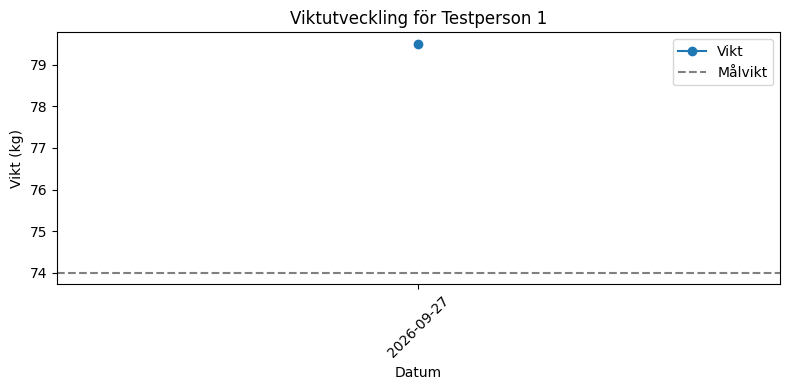

Diagrammet sparat som testperson1_weight_chart.png

1. Logga dagens data
2. Visa analys
3. Visa viktdiagram
4. Läs in loggar från CSV
5. Spara och avsluta
Profilen sparad i testperson1_profile.json
Skapar ny fil: testperson1_logs.csv
Sparade 1 loggar i testperson1_logs.csv
Hej då!

Antal loggar efter körningen: 1


In [3]:
answers = [
    "178", "29", "kvinna", "80", "74",            # create_profile
    "1", "", "79.5", "2000", "150", "9000", "j",  # menyval 1: logga dagen
    "2",                                           # menyval 2: analys
    "3",                                           # menyval 3: diagram
    "5",                                           # menyval 5: spara och avsluta
]

with patch("builtins.input", side_effect=answers):
    show_welcome()
    profile_1 = create_profile("Testperson 1")
    run_menu(profile_1)

print("\nAntal loggar efter körningen:", len(profile_1.logs))

## Test 2: analys på ett större underlag

Samma klasser, men med fjorton genererade loggar för **Testperson** istället
för en enda, så att `check_goals` och diagrammet har något substantiellt att
visa. `random.seed(42)` gör körningen upprepningsbar, samma resultat varje
gång notebooken körs om.

In [4]:
import random
from datetime import timedelta

profile_2 = CutProfile(
    name="Testperson",
    height_cm=180,
    age=32,
    sex="man",
    start_weight=92.0,
    goal_weight=85.0,
)

random.seed(42)
start_date = datetime(2026, 9, 1)
weight = profile_2.start_weight

for i in range(14):
    date = (start_date + timedelta(days=i)).strftime("%Y-%m-%d")
    weight = round(weight - random.uniform(0.05, 0.2), 1)
    calories = round(random.uniform(1900, 2300))
    protein = round(random.uniform(140, 190))
    steps = round(random.uniform(5000, 11000))
    trained = random.random() < 0.5

    log = DailyLog(date, weight, calories, protein, steps, trained)
    profile_2.add_log(log)

print(f"{profile_2.name} har nu {len(profile_2.logs)} loggar.")

for message in profile_2.check_goals(days=7):
    print("-", message)

Testperson har nu 14 loggar.
- Vikten har gått ner 0.9 kg de senaste 7 loggarna. Rätt riktning.
- Proteinmålet nås inte: snitt 159.3 g mot mål 161.5 g.
- Stegmålet nås: snitt 8332 steg mot mål 8000.
- Träningsmålet nås: 4 pass mot mål 3.


## Spara, läsa tillbaka och exportera

Kör mot de riktiga filerna: `save_profile` och `export_logs_csv` sparar
**Testperson**s data, `load_profile` läser tillbaka den, och
**Testperson 3** används bara för att visa att `import_logs_csv` kan läsa
in loggar sparade av en annan profil.

Profilen sparad i testperson_profile.json
Profilen Testperson inläst från testperson_profile.json
Skapar ny fil: testperson_logs.csv
Sparade 14 loggar i testperson_logs.csv
Importerade 14 loggar, hoppade över 0 felaktiga rader.


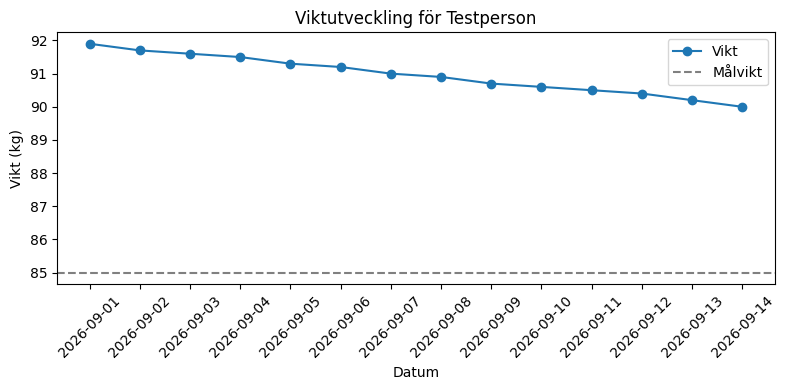

Diagrammet sparat som testperson_weight_chart.png


In [5]:
save_profile(profile_2)
reloaded = load_profile("Testperson")

export_logs_csv(profile_2)

profile_3 = CutProfile("Testperson 3", 180, 32, "man", 92.0, 85.0)
import_logs_csv(profile_3, make_filename("Testperson", "logs.csv"))

plot_weight(profile_2)

## Var varje krav täcks

| Krav | Var |
| --- | --- |
| Variabler och datatyper | str, float, int, bool, list, dict |
| If-satser | validering i `DailyLog`, `check_goals`, `load_profile`, `import_logs_csv`, `create_profile`, `run_menu` |
| Loopar | `for` i average-metoderna, CSV-export/import, loggenerering. `while` i `ask_number`, `ask_yes_no`, kön-frågan i `create_profile`, huvudloopen i `run_menu` |
| Funktioner | `make_filename`, `save_profile`, `load_profile`, `export_logs_csv`, `import_logs_csv`, `plot_weight`, `show_welcome`, `ask_number`, `ask_yes_no`, `create_profile`, `log_today`, `run_menu` |
| Felhantering | `ValueError` i `DailyLog`, tre `except`-block i `load_profile`, `try/except` per rad i `import_logs_csv`, `OSError` i spara-funktionerna, `ValueError` i `log_today` |
| Datahantering | JSON (`save_profile`/`load_profile`) och CSV (`export_logs_csv`/`import_logs_csv`) |
| Klasser | `DailyLog`, `User` |
| Arv | `CutProfile(User)` med `super().__init__()` |
| Standardbibliotek | `json`, `csv`, `os`, `random`, `datetime` |
| Externt bibliotek | `matplotlib` |
| API eller extern data | CSV-inläsning (`import_logs_csv`) |
| GitHub | Repo med `models.py`, `analysis.py`, notebooken |

## VG-kriterier, kod-delen

| VG-krav | Uppfyllt av |
| --- | --- |
| Kodstruktur, flera moduler | `models.py` + `analysis.py` + notebooken |
| Namngivning enligt PEP 8 | Engelska namn på klasser/funktioner/variabler genomgående |
| Specifik felhantering per feltyp | Tre skilda except i `load_profile`, `OSError` separat från `ValueError` |
| Extra funktionalitet utöver minimikraven | Interaktiv meny, CSV-import som eget menyval, säkert filnamn via `make_filename` |
| Visualisering integrerad i lösningen | `plot_weight` anropas från menyn, inte en fristående lös bild |

Kvar utanför koden: 15+ commits, README med analys/certifikat/reflektion.